In [17]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import glob
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, recall_score, f1_score
from interpret.glassbox import ExplainableBoostingClassifier
from interpret.glassbox import merge_ebms
import time
from helper_funcs import convert_hot_encodings, scale_features
from classify_with_scaling import get_zero_score_names, remove_zero_score_terms_by_name

In [5]:
from interpret import set_visualize_provider
from interpret.provider import InlineProvider
set_visualize_provider(InlineProvider())
from interpret import show

In [6]:
np.random.seed(42)
label_encoder = LabelEncoder()

### List the EBMs to be merged together
_Example_: 
models = [NYGC1_model, NYGC2_model, BLGSP_model, HTMCP_model]

In [ ]:
models = []

### Merge EBMs into one Model

In [ ]:
zero_score_names = get_zero_score_names(models)
if len(models) > 1:
    for model in models:
        model = remove_zero_score_terms_by_name(model, zero_score_names)
        model_feature_index = {name: i for i, name in enumerate(model.feature_names_in_)}
        reorder_indices = [model_feature_index[name] for name in models[0].feature_names_in_]
        
        model.feature_names_in_ = [model.feature_names_in_[i] for i in reorder_indices]
        model.term_names_ = [model.term_names_[i] for i in reorder_indices]
        model.feature_types_in_ = [model.feature_types_in_[i] for i in reorder_indices]

In [ ]:
ebm = merge_ebms(models)

#### If applicable, save the merged model

In [7]:
output_path = None 

In [8]:
if output_path: 
    print(f'Output path provided; Merged model saved to: {output_path}')
    with open(output_path, 'wb') as file:
        pickle.dump(ebm, file)

## Evaluate Merged FIFA Model
### Test in HCC1395 Cell Line Data

In [ ]:
directory = "/gpfs/commons/groups/compbio/projects/FFPE_filtering/seqc2/extracted_features/"
pattern = "*_extracted_features.csv"

matching_files = glob.glob(directory + pattern, recursive=True)
try: 
    features = pd.concat((pd.read_csv(f).fillna(0) for f in matching_files), ignore_index=True)
    features = features.drop(['Cohort_x', 'Cohort_y', '0'], axis=1)
    features['Cohort'] = 'HCC1395'
    features['tumor_depth'] = 0
except Exception as e:
    print(f"An error occurred: {e}")
labels_path="/gpfs/commons/groups/compbio/projects/FFPE_filtering/seqc2/replicating_deepsom/real_labels.csv"
labels = pd.read_csv(labels_path, sep=',').fillna(0)
labels['Label'] = labels['Label'].apply(lambda x: 1 if x == 'Real' else 0)
variants = pd.merge(features, labels, on=['Sample', 'Variant'], how='inner')

if 'hot_encoded_ref_base' in variants.columns:
    variants = convert_hot_encodings(variants)
variants = scale_features(variants)

In [ ]:
print(f'Metrics in HCC1395 Cell Line Replicates (chr1 variants)')
for sample in variants[variants['Cohort'] == 'HCC1395']['Sample'].unique():
    testing_set = variants[(variants['Sample'] == sample) & (variants['Variant'].str.startswith('chr1:'))].drop(['Sample', 'Variant', 'Cohort'], axis=1)

    X_test = testing_set.drop(['Label'], axis=1)
    y_test = label_encoder.fit_transform(testing_set['Label'])
    
    y_pred = ebm.predict(X_test)
    
    print(f'Mutect2 calls from {sample}')
    f1 = f1_score(y_test, y_pred)
    print("F1: {:.3f}".format(f1))
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy: {:.3f}".format(accuracy))
    
    precision = precision_score(y_test, y_pred)
    print("Precision: {:.3f}".format(precision))
    
    recall = recall_score(y_test, y_pred)
    print("Recall: {:.3f}".format(recall))

### Compare Global Feature Importance Rankings
For the models uploaded and merged together, show the top contributing features

In [10]:
with open('/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/ebm_hyperparams_DLBCL.pkl', 'rb') as file:
    ebm1 = pickle.load(file)
with open('/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/ebm_hyperparams_ROT.pkl', 'rb') as file:
    ebm2 = pickle.load(file)
with open('/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/ebm_hyperparams_CGCI-BLGSP.pkl', 'rb') as file:
    ebm3 = pickle.load(file)
with open('/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/ebm_hyperparams_CGCI-HTMCP.pkl', 'rb') as file:
    ebm4 = pickle.load(file)

In [11]:
ebm_global_1 = ebm1.explain_global().data()
ebm_global_2 = ebm2.explain_global().data()
ebm_global_3 = ebm3.explain_global().data()
ebm_global_4 = ebm4.explain_global().data()

all_features = pd.DataFrame(columns=['Feature', 'NYGC1', 'NYGC2', 'BLGSP', 'HTMCP']) #

for feature in ebm_global_1['names']:
    if not ((feature in ebm_global_2['names']) & (feature in ebm_global_3['names']) & (feature in ebm_global_4['names'])):#   # 
        continue
    else:
        i_1 = next((i for i, name in enumerate(ebm_global_1['names']) if name == feature), 0)
        i_2 = next((i for i, name in enumerate(ebm_global_2['names']) if name == feature), 0)
        i_3 = next((i for i, name in enumerate(ebm_global_3['names']) if name == feature), 0)
        i_4 = next((i for i, name in enumerate(ebm_global_4['names']) if name == feature), 0)
        
        row = {
            'Feature': feature,
            'NYGC1': ebm_global_1['scores'][i_1],
            'NYGC2': ebm_global_2['scores'][i_2],
            'BLGSP': ebm_global_3['scores'][i_3],
            'HTMCP': ebm_global_4['scores'][i_4]
        }
        all_features = all_features.append(row, ignore_index=True)


filtered_features = all_features[
    (all_features['NYGC2'] + all_features['NYGC1'] + all_features['BLGSP'] + all_features['HTMCP']) >= 0.45 #
]

filtered_features['NYGC1'] = filtered_features['NYGC1'] / filtered_features['NYGC1'].max()
filtered_features['NYGC2'] = filtered_features['NYGC2'] / filtered_features['NYGC2'].max()
filtered_features['BLGSP'] = filtered_features['BLGSP'] / filtered_features['BLGSP'].max()
filtered_features['HTMCP'] = filtered_features['HTMCP'] / filtered_features['HTMCP'].max()

filtered_features = filtered_features.sort_values(by='HTMCP', ascending=False)

all_features_long = filtered_features.melt(
    id_vars='Feature',
    value_vars=all_features.columns[1:], 
    var_name='Cohort',
    value_name='Value'
)

/nfs/home/vgrether/.conda/envs/FFPE/lib/python3.7/site-packages/ipykernel_launcher.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/vgrether/.conda/envs/FFPE/lib/python3.7/site-packages/ipykernel_launcher.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/vgrether/.conda/envs/FFPE/lib/python3.7/site-packages/ipykernel_launcher.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

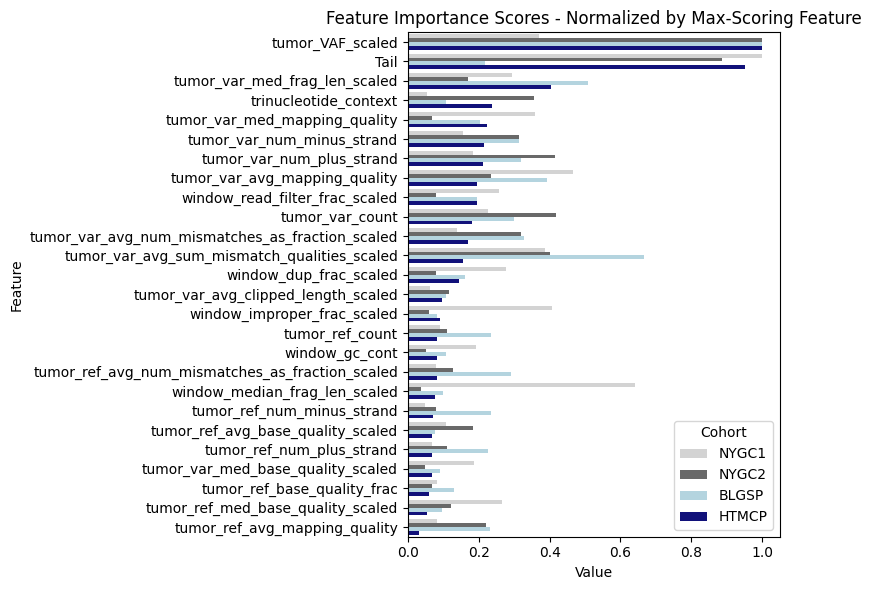

In [18]:
custom_palette = ["lightgrey", "dimgray", "lightblue", "darkblue"]
plt.figure(figsize=(8,6))
sns.barplot(
    data=all_features_long,
    y='Feature',
    x='Value',
    hue='Cohort',
    palette=custom_palette,
    orient='h'
)
plt.title('Feature Importance Scores - Normalized by Max-Scoring Feature')
plt.xlabel('Value')
#plt.legend(title='Model')
plt.ylabel('Feature')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Compare Individual Feature Scoring Functions